In [1]:
import torch
from torch import nn
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
import time
from torch.nn.parameter import Parameter

NUM_USER=30
def softmax(x):
    ex = np.exp(x)
    sum_ex = np.sum( np.exp(x))
    return ex/sum_ex

def generate_synthetic(alpha, beta,iid):
    dimension = 60
    NUM_CLASS = 10
    samples_per_user = np.random.lognormal(4, 2, (NUM_USER)).astype(int) + 50
    num_samples = np.sum(samples_per_user)
    X_split = [[] for _ in range(NUM_USER)]
    y_split = [[] for _ in range(NUM_USER)]
    #### define some eprior ####
    if(iid==0):
        mean_W = np.random.normal(0, alpha, NUM_USER)
        mean_b = mean_W
        B = np.random.normal(0, beta, NUM_USER)
        mean_x = np.zeros((NUM_USER, dimension))
        diagonal = np.zeros(dimension)
        for j in range(dimension):
            diagonal[j] = np.power((j+1), -1.2)
        cov_x = np.diag(diagonal)

        for i in range(NUM_USER):
            mean_x[i] = np.random.normal(B[i], 1, dimension)

        for i in range(NUM_USER):

            W = np.random.normal(mean_W[i], 1, (dimension, NUM_CLASS))
            b = np.random.normal(mean_b[i], 1,  NUM_CLASS)

            xx = np.random.multivariate_normal(mean_x[i], cov_x, samples_per_user[i]*2)
            yy = np.zeros(samples_per_user[i]*2)

            for j in range(samples_per_user[i]):
                tmp = np.dot(xx[j], W) + b
                yy[j] = np.argmax(softmax(tmp))

            X_split[i] = xx.tolist()
            y_split[i] = yy.tolist()
    if(iid==1):
        mean_W = np.random.normal(0, alpha,1)
        mean_b = mean_W
        B = np.random.normal(0, beta, 1)
        mean_x = np.random.normal(B, 1, dimension)
        diagonal = np.zeros(dimension)
        for j in range(dimension):
            diagonal[j] = np.power((j+1), -1.2)
        cov_x = np.diag(diagonal)

        W = np.random.normal(mean_W, 1, (dimension, NUM_CLASS))
        b = np.random.normal(mean_b, 1,  NUM_CLASS)
            
        for i in range(NUM_USER):


            xx = np.random.multivariate_normal(mean_x, cov_x, samples_per_user[i]*2)
            yy = np.zeros(samples_per_user[i]*2)

            for j in range(samples_per_user[i]):
                tmp = np.dot(xx[j], W) + b
                yy[j] = np.argmax(softmax(tmp))

            X_split[i] = xx.tolist()
            y_split[i] = yy.tolist()
        
    return X_split, y_split,samples_per_user

#创建用户类
class Client():
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.w_cur=[]
        self.number=len(y)


#创建SGD——softmax模型类
class linearNet(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super(linearNet, self).__init__()
        self.linear = nn.Linear(num_inputs, num_outputs)
    def forward(self, x):
        y = self.linear(x.view(x.shape[0], -1))
        return y

class optimizer:
    def __init__(self,client,w0,batchsize=10,yita=0,miu=0,step=20):
        self.x=client.x
        self.y=client.y
        self.num = len(client.y)
        # 输入：一通道61*1的向量, 输出：10个分类对应十个输出,加上了一列全为1的向量
        self.net = linearNet(1*61*1, 10 )
        self.net.linear.weight=Parameter(w0)  #初始化网络参数权值
        nn.init.constant_(self.net.linear.bias,0)
        
        self.optimizer = torch.optim.SGD(self.net.parameters(), lr=0.001)   #优化器
        self.step=step
        self.batchsize=batchsize
        self.miu=miu
        self.yita=yita
        #把模型转移到GPU上
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        self.device=device
        self.net.to(device)
        #把数据转移到GPU上
        self.x = self.x.cuda(device)
        self.y = self.y.cuda(device)
        
        self.loss = nn.CrossEntropyLoss().to(device)   #定义交叉熵损失函数,  这个方法集成了softmax计算

    # 测试集数据评估
    def evaluate_accuracy(self,client):
        client.x=client.x.cuda(self.device)
        client.y=client.y.cuda(self.device)
        acc_sum = (self.net(client.x.float()).argmax(dim=1).cuda(self.device) == client.y.type(torch.LongTensor).cuda(self.device)).float().sum().item()
        return acc_sum/len(client.y)


    def train_model_prox(self,miu=0):
        w0=self.net.linear.weight.detach()
        for epoch in range(self.step):
            batch_num=self.num//self.batchsize
            row_indice=np.random.permutation(self.num)
            for h in range(batch_num):
                # 随机选择
                s = row_indice[h*self.batchsize:(h+1)*self.batchsize]
                    # 得到该样本的特征向量和标记
                x = self.x[s]
                y=self.y[s]
                y_hat = self.net(x.float())
                cost = self.loss(y_hat, y.type(torch.LongTensor).cuda(self.device)).sum()+0.5*self.miu*torch.norm(self.net.linear.weight.detach()-w0)**2
                self.optimizer.zero_grad()
                cost.backward()
                self.optimizer.step()
        return  self.net.linear.weight.detach()
    
    def train_model_prior(self):
        w0=self.net.linear.weight.detach()
        y_hat_prior_total=self.net(self.x.float()).argmax(dim=1)
        for epoch in range(self.step):
            batch_num=self.num//self.batchsize
            row_indice=np.random.permutation(self.num)
            for h in range(batch_num):
                # 随机选择
                s = row_indice[h*self.batchsize:(h+1)*self.batchsize]
                    # 得到该样本的特征向量和标记
                x = self.x[s]
                y=self.y[s]
                y_hat_prior=y_hat_prior_total[s]
                y_hat = self.net(x.float())
                #yita和miu能否同时使用prox中的dynamic miu?
                cost = self.loss(y_hat, y.type(torch.LongTensor).cuda(self.device)).sum()+self.yita*self.loss(y_hat,y_hat_prior.type(torch.LongTensor)).sum()
                self.optimizer.zero_grad()
                cost.backward()
                self.optimizer.step()
        return  self.net.linear.weight.detach()
    
    def cal_loss(self):
        y_hat = self.net(self.x.float())
        cost = self.loss(y_hat, self.y.type(torch.LongTensor).cuda(self.device)).sum()
        return cost.detach()

def Global(rounds,client,batchsize=10):
    global_w=torch.zeros((10,61))
    training_loss=[]
    train_accuracy=[]
    test_accuracy=[]

    for i in range(0,rounds):

        p=optimizer(client,global_w,batchsize=batchsize)
        training_loss.append(p.cal_loss())
        train_accuracy.append(p.evaluate_accuracy(global_client))
        test_accuracy.append(p.evaluate_accuracy(test_client))

        global_w=p.train_model_prox()


    return global_w,training_loss,train_accuracy,test_accuracy
    
    
    
    
def FedAvg(rounds,client_list,batchsize=10):
    w_total_cur=torch.zeros((10,61))
    training_loss=[]
    train_accuracy=[]
    test_accuracy=[]
   
    for i in range(0,rounds):
        total_p=optimizer(global_client,w_total_cur)
        training_loss.append(total_p.cal_loss())  
        train_accuracy.append(total_p.evaluate_accuracy(global_client))
        test_accuracy.append(total_p.evaluate_accuracy(test_client))
        
        np.random.seed(i)
        selected_clients=np.random.choice(client_list, select_clients, replace=False)
        active_clients=np.random.choice(selected_clients, round(select_clients*(1-straggler_rate)), replace=False)
        sample_num=0
        w0=w_total_cur.detach()
        w_total_cur=torch.zeros((10,61))
        for c in active_clients:
            p=optimizer(c,w0,batchsize=batchsize)
            c.w_cur=p.train_model_prox()
            sample_num+=c.number
            w_total_cur+=c.w_cur*c.number
        w_total_cur= w_total_cur/sample_num
        
             
    return w_total_cur,training_loss,train_accuracy,test_accuracy

def FedProx(rounds,client_list,batchsize=10):
    miu=0
    count_miu_decrease=0
    training_loss=[]
    train_accuracy=[]
    test_accuracy=[]
    w_total_cur=torch.zeros((10,61))


   
    for i in range(0,rounds):
        total_p=optimizer(global_client,w_total_cur)
        prox_loss=total_p.cal_loss()
        training_loss.append(prox_loss)  
        train_accuracy.append(total_p.evaluate_accuracy(global_client))
        test_accuracy.append(total_p.evaluate_accuracy(test_client))
        
        np.random.seed(i)
        selected_clients=np.random.choice(client_list, select_clients, replace=False)
        active_clients=np.random.choice(selected_clients, round(select_clients*(1-straggler_rate)), replace=False)
        sample_num=0
        w0=w_total_cur.detach()
        w_total_cur=torch.zeros((10,61))
        for c in selected_clients:
            if c in active_clients: 
                p=optimizer(c,w0,batchsize=batchsize,miu=miu)
                c.w_cur=p.train_model_prox()
                sample_num+=c.number
                w_total_cur+=c.w_cur*c.number   
            else:
                step=np.random.randint(1,20)
                p=optimizer(c,w0,batchsize=batchsize,miu=miu,step=step)
                c.w_cur=p.train_model_prox()
                sample_num+=c.number
                w_total_cur+=c.w_cur*c.number
            
                
                
        w_total_cur= w_total_cur/sample_num
        
        if(i>0):
            if(training_loss[i-1]>=prox_loss):
                count_miu_decrease+=1
            if(training_loss[i-1]<prox_loss):
                miu+=0.1
                count_miu_decrease=0
        if(count_miu_decrease>=5 and miu>0):
            miu-=0.1
            count_miu_decrease=0
        
    return w_total_cur,training_loss,train_accuracy,test_accuracy

def FedPrior(rounds,client_list,yita,batchsize=10):
    w_total_cur=torch.zeros((10,61))
    training_loss=[]
    train_accuracy=[]
    test_accuracy=[]
   
    for i in range(0,rounds):
        total_p=optimizer(global_client,w_total_cur)
        training_loss.append(total_p.cal_loss())  
        train_accuracy.append(total_p.evaluate_accuracy(global_client))
        test_accuracy.append(total_p.evaluate_accuracy(test_client))
        
        np.random.seed(i)
        selected_clients=np.random.choice(client_list, select_clients, replace=False)
        active_clients=np.random.choice(selected_clients, round(select_clients*(1-straggler_rate)), replace=False)
        sample_num=0
        w0=w_total_cur.detach()
        w_total_cur=torch.zeros((10,61))
        for c in active_clients:
            p=optimizer(c,w0,batchsize=batchsize,yita=yita)
            c.w_cur=p.train_model_prior()
            sample_num+=c.number
            w_total_cur+=c.w_cur*c.number
        w_total_cur= w_total_cur/sample_num
        
             
    return w_total_cur,training_loss,train_accuracy,test_accuracy

def PriorProx(rounds,client_list,yita,batchsize=10):
    training_loss=[]
    train_accuracy=[]
    test_accuracy=[]
    w_total_cur=torch.zeros((10,61))


   
    for i in range(0,rounds):
        total_p=optimizer(global_client,w_total_cur)
        prox_loss=total_p.cal_loss()
        training_loss.append(prox_loss)  
        train_accuracy.append(total_p.evaluate_accuracy(global_client))
        test_accuracy.append(total_p.evaluate_accuracy(test_client))
        
        np.random.seed(i)
        selected_clients=np.random.choice(client_list, select_clients, replace=False)
        active_clients=np.random.choice(selected_clients, round(select_clients*(1-straggler_rate)), replace=False)
        sample_num=0
        w0=w_total_cur
        w_total_cur=torch.zeros((10,61))
        for c in selected_clients:
            if c in active_clients: 
                p=optimizer(c,w0,batchsize=batchsize,yita=yita)
                c.w_cur=p.train_model_prox()
                sample_num+=c.number
                w_total_cur+=c.w_cur*c.number   
            else:
                step=np.random.randint(1,20)
                p=optimizer(c,w0,batchsize=batchsize,yita=yita,step=step)
                c.w_cur=p.train_model_prior()
                sample_num+=c.number
                w_total_cur+=c.w_cur*c.number
            
                
                
        w_total_cur= w_total_cur/sample_num
        
    return w_total_cur,training_loss,train_accuracy,test_accuracy

# Figure1

## 0% stragglers

In [4]:
rounds=200
straggler_rate=0
select_clients=10
clients_num=30
batchsize=10
beta=1
alpha=1
yita=0.1

In [5]:
#产生数据
X, y,num= generate_synthetic(alpha=alpha, beta=beta, iid=0) 

In [6]:
client_list=[]
for i in range(0,clients_num):
    x1=X[i]
    y1=y[i]
    b=np.ones(len(y1))
    x1=np.c_[x1,b]
    client1=Client(torch.tensor(x1[0:num[i]]),torch.tensor(y1[0:num[i]]))
    client_list.append(client1)
    if i<1:
        test_x=torch.tensor(x1[num[i]:])
        test_y=torch.tensor(y1[num[i]:])
        x_global=torch.tensor(x1[0:num[i]])
        y_global=torch.tensor(y1[0:num[i]])
    elif i>=1:
        test_x=torch.vstack((test_x,torch.tensor(x1[num[i]:])))
        test_y=torch.hstack((test_y,torch.tensor(y1[num[i]:])))
        x_global=torch.vstack((x_global,torch.tensor(x1[0:num[i]])))
        y_global=torch.hstack((y_global,torch.tensor(y1[0:num[i]])))
    
global_client=Client(x_global,y_global)
test_client=Client(test_x,test_y)

In [7]:
global_w,loss0,global_train,global_test=Global(rounds,global_client,batchsize)
avg_w,loss1,avg_train,avg_test=FedAvg(rounds,client_list,batchsize)
prox_w,loss2,prox_train,prox_test=FedProx(rounds,client_list,batchsize)
prior_w,loss3,prior_train,prior_test=FedPrior(rounds,client_list,yita,batchsize)
pp_w,loss4,pp_train,pp_test=PriorProx(rounds,client_list,yita,batchsize)

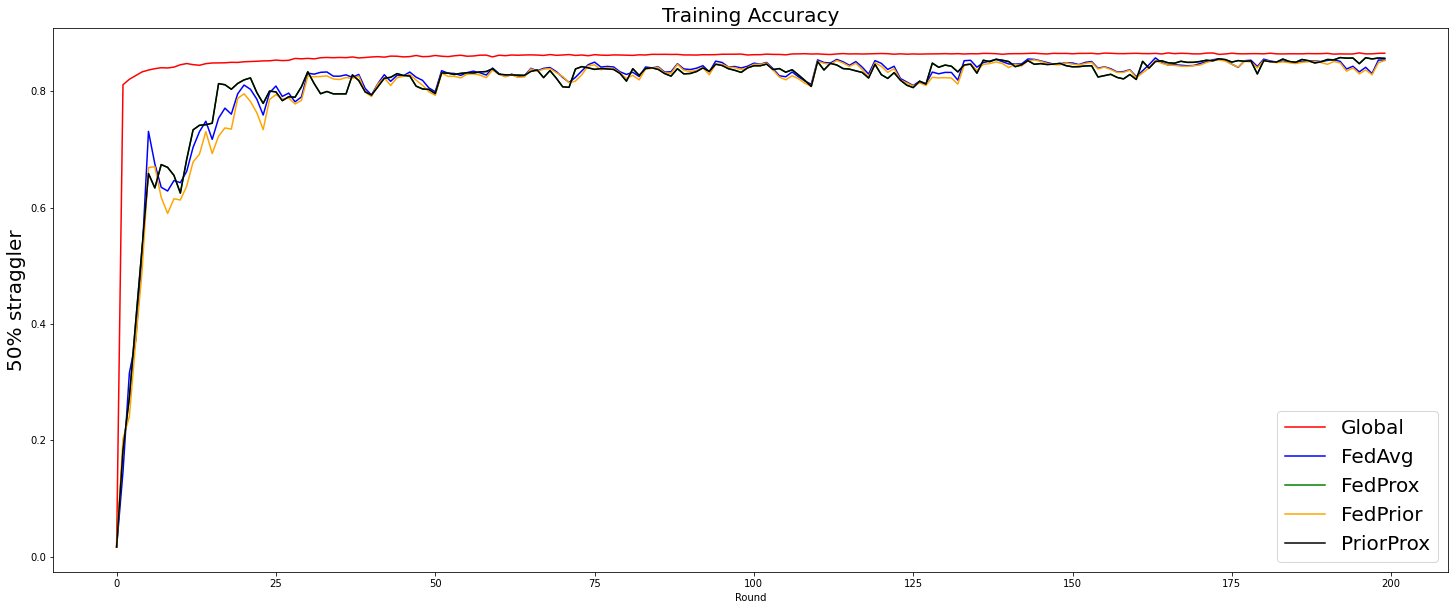

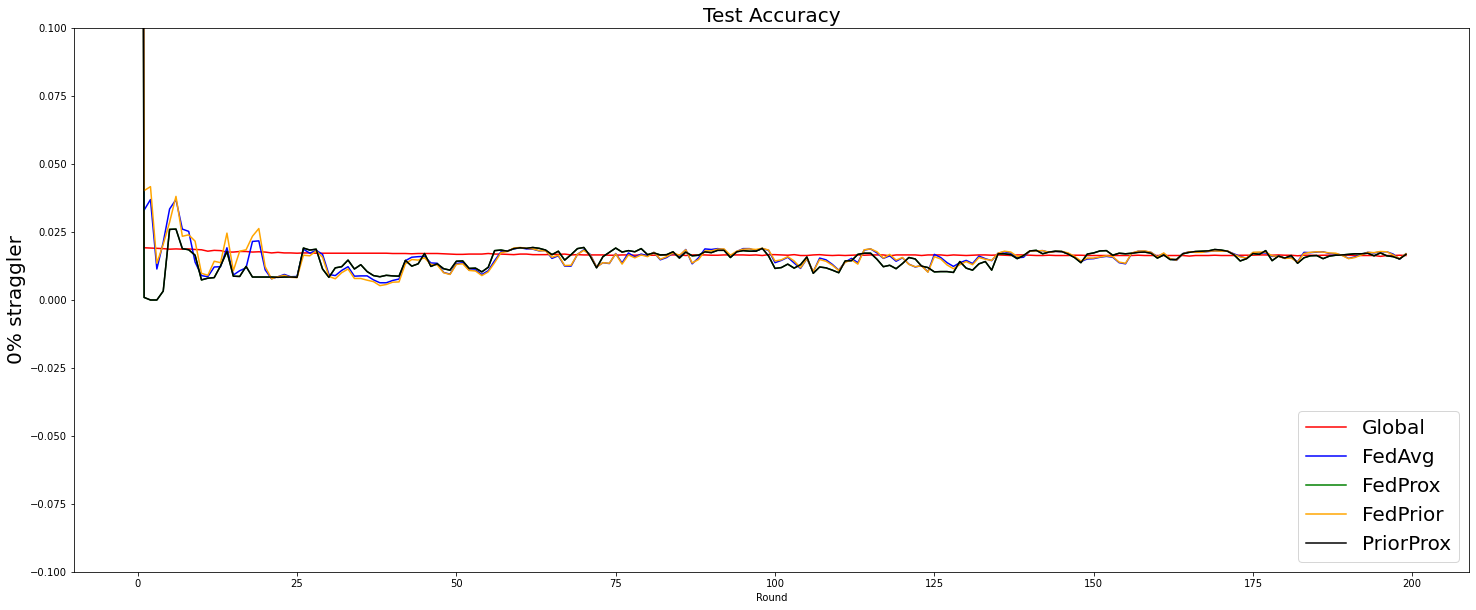

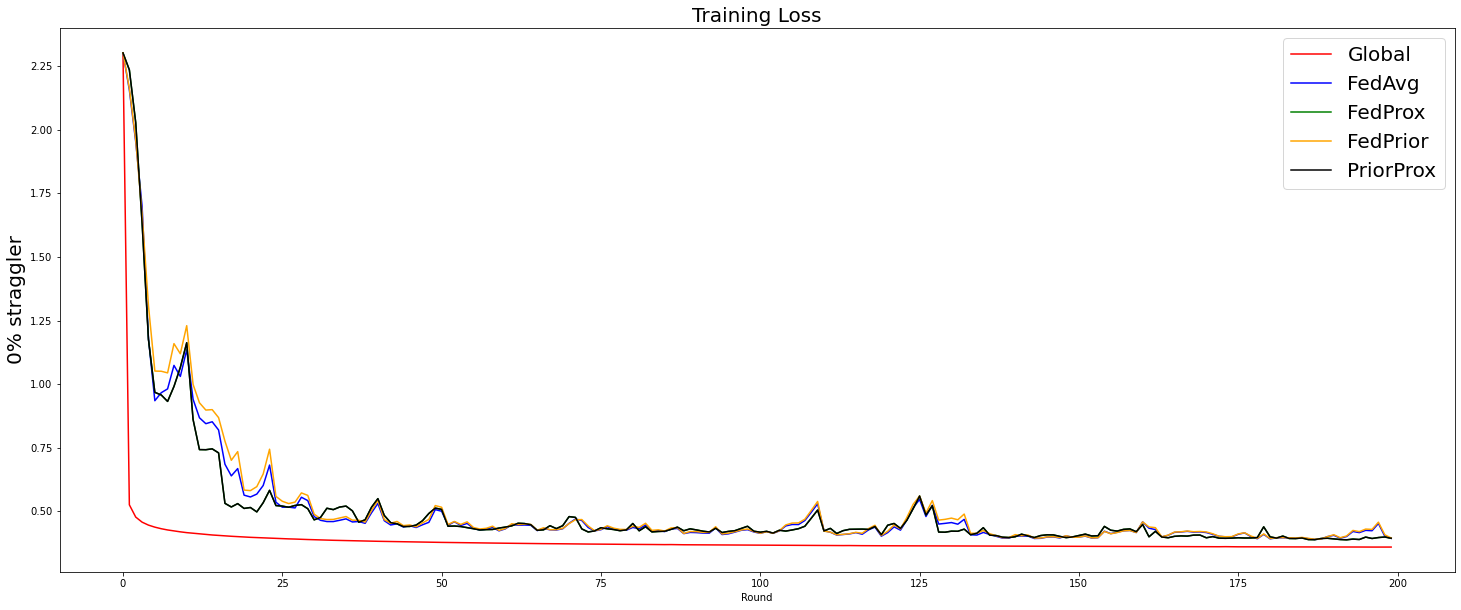

In [18]:
plt.figure(figsize=(25,10))
plt.plot(global_train,color='red')
plt.plot(avg_train,color='blue')
plt.plot(prox_train,color='green')
plt.plot(prior_train,color='orange')
plt.plot(pp_train,color='black')
plt.xlabel('Round')
plt.ylabel('50% straggler',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
plt.plot(global_test,color='red')
plt.plot(avg_test,color='blue')
plt.plot(prox_test,color='green')
plt.plot(prior_test,color='orange')
plt.plot(pp_test,color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Test Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)
plt.ylim((-0.1,0.1))

plt.figure(figsize=(25,10))
#plt.ylim((-0.1,50))
plt.plot(np.squeeze(loss0),color='red')
plt.plot(np.squeeze(loss1),color='blue')
plt.plot(np.squeeze(loss2),color='green')
plt.plot(np.squeeze(loss3),color='orange')
plt.plot(np.squeeze(loss4),color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)

## 50% stragglers

In [22]:
straggler_rate=0.5
#global_w,loss0,global_train,global_test

In [23]:
avg_w_5,loss1_5,avg_train_5,avg_test_5=FedAvg(rounds,client_list,batchsize)
prox_w_5,loss2_5,prox_train_5,prox_test_5=FedProx(rounds,client_list,batchsize)
prior_w_5,loss3_5,prior_train_5,prior_test_5=FedPrior(rounds,client_list,yita,batchsize)
pp_w_5,loss4_5,pp_train_5,pp_test_5=PriorProx(rounds,client_list,yita,batchsize)

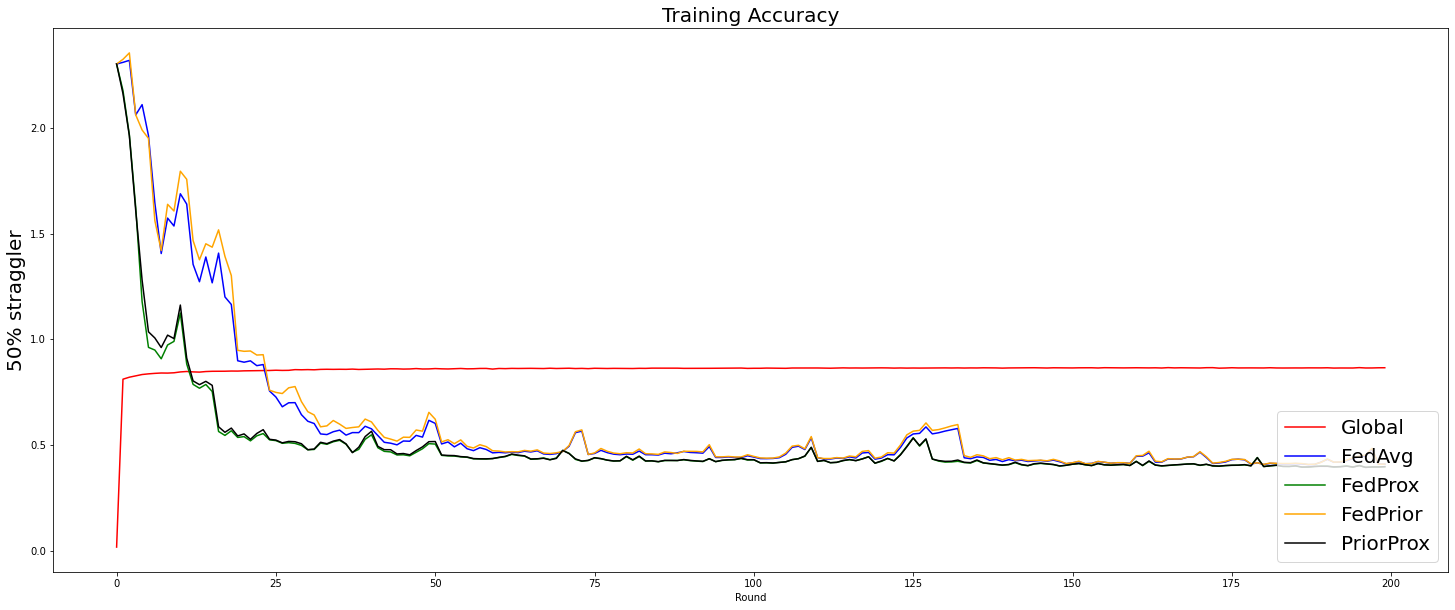

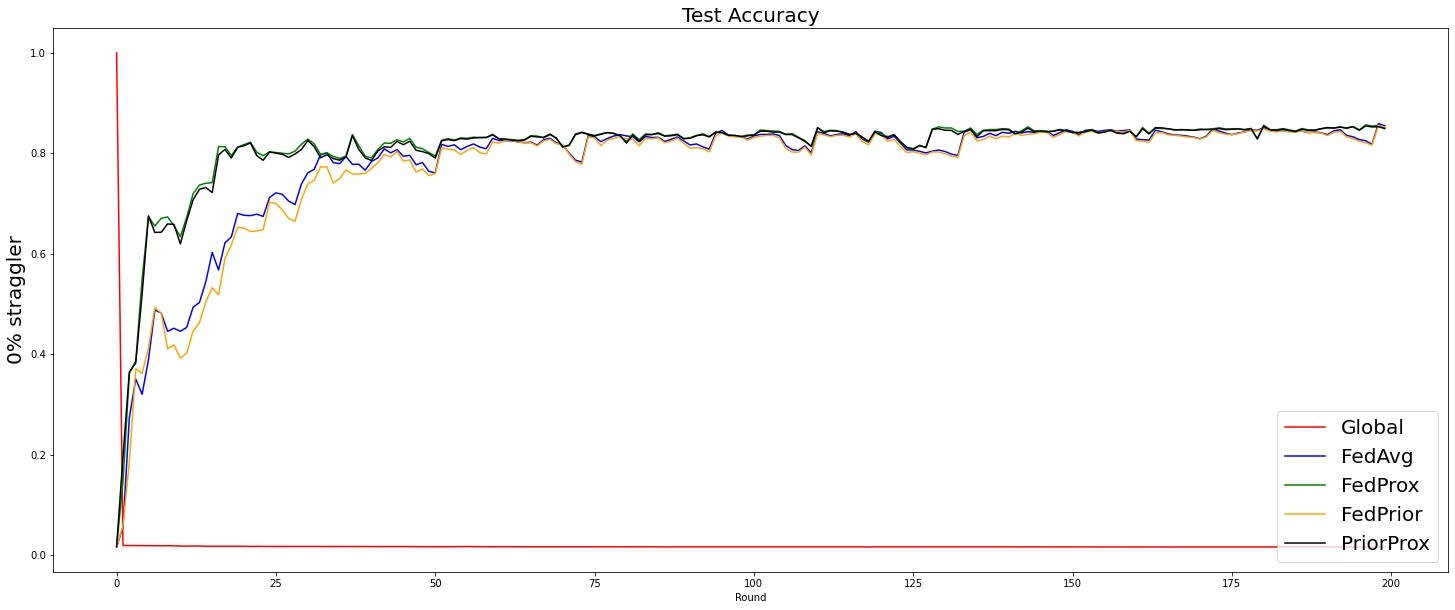

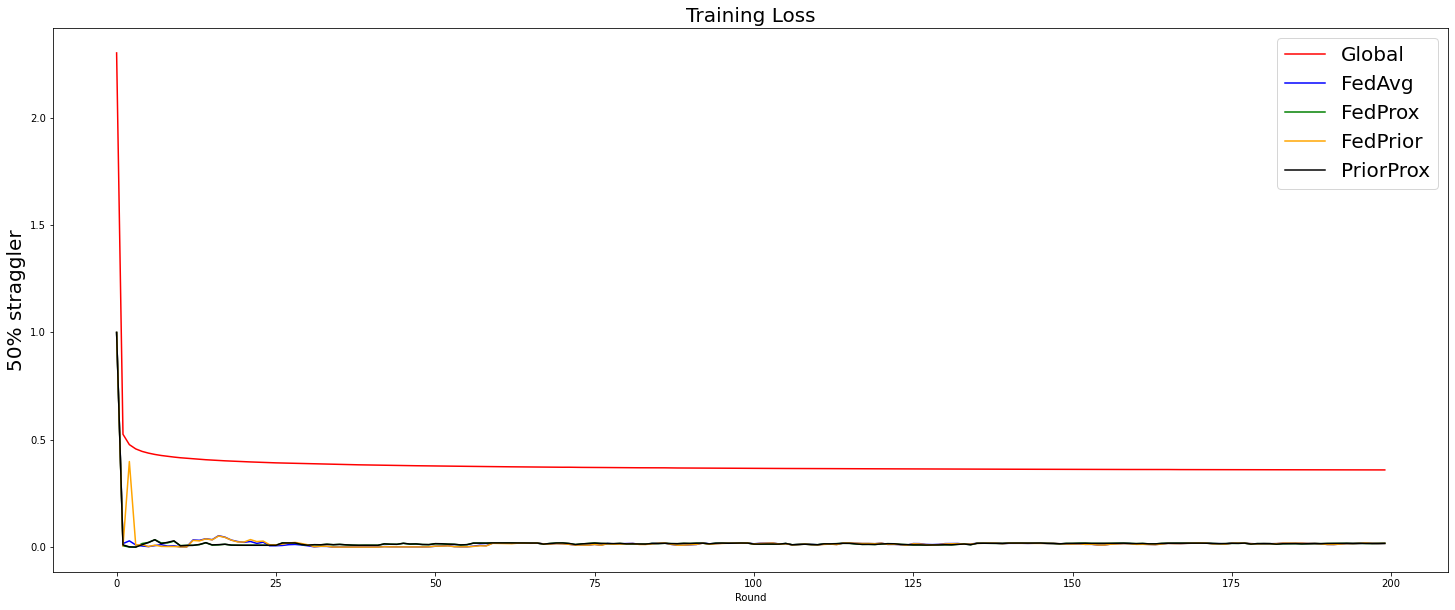

In [24]:
plt.figure(figsize=(25,10))
plt.plot(loss0,color='red')
plt.plot(avg_train_5,color='blue')
plt.plot(prox_train_5,color='green')
plt.plot(prior_train_5,color='orange')
plt.plot(pp_train_5,color='black')
plt.xlabel('Round')
plt.ylabel('50% straggler',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
plt.plot(global_train,color='red')
plt.plot(avg_test_5,color='blue')
plt.plot(prox_test_5,color='green')
plt.plot(prior_test_5,color='orange')
plt.plot(pp_test_5,color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Test Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
#plt.ylim((-0.1,50))
plt.plot(np.squeeze(loss0),color='red')
plt.plot(np.squeeze(loss1_5),color='blue')
plt.plot(np.squeeze(loss2_5),color='green')
plt.plot(np.squeeze(loss3_5),color='orange')
plt.plot(np.squeeze(loss4_5),color='black')
plt.xlabel('Round')
plt.ylabel('50% straggler',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)

## 90% stragglers

In [25]:
straggler_rate=0.9

In [26]:
avg_w_9,loss1_9,avg_train_9,avg_test_9=FedAvg(rounds,client_list,batchsize)
prox_w_9,loss2_9,prox_train_9,prox_test_9=FedProx(rounds,client_list,batchsize)
prior_w_9,loss3_9,prior_train_9,prior_test_9=FedPrior(rounds,client_list,yita,batchsize)
pp_w_9,loss4_9,pp_train_9,pp_test_9=PriorProx(rounds,client_list,yita,batchsize)

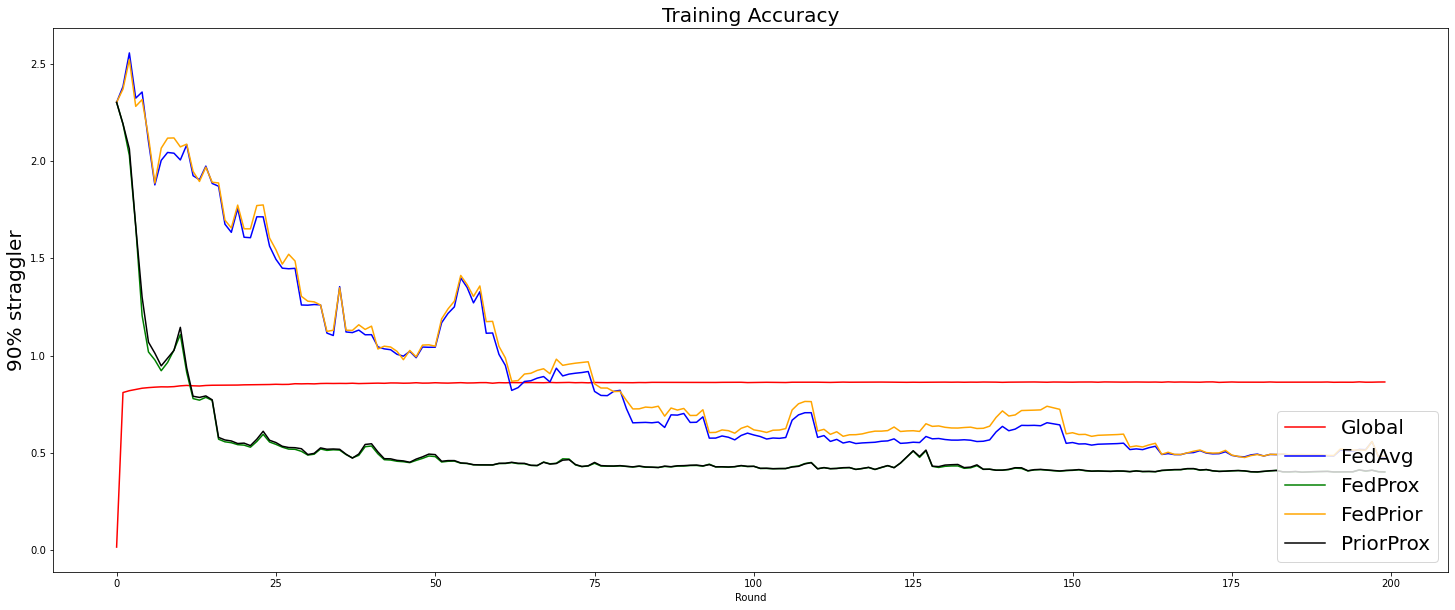

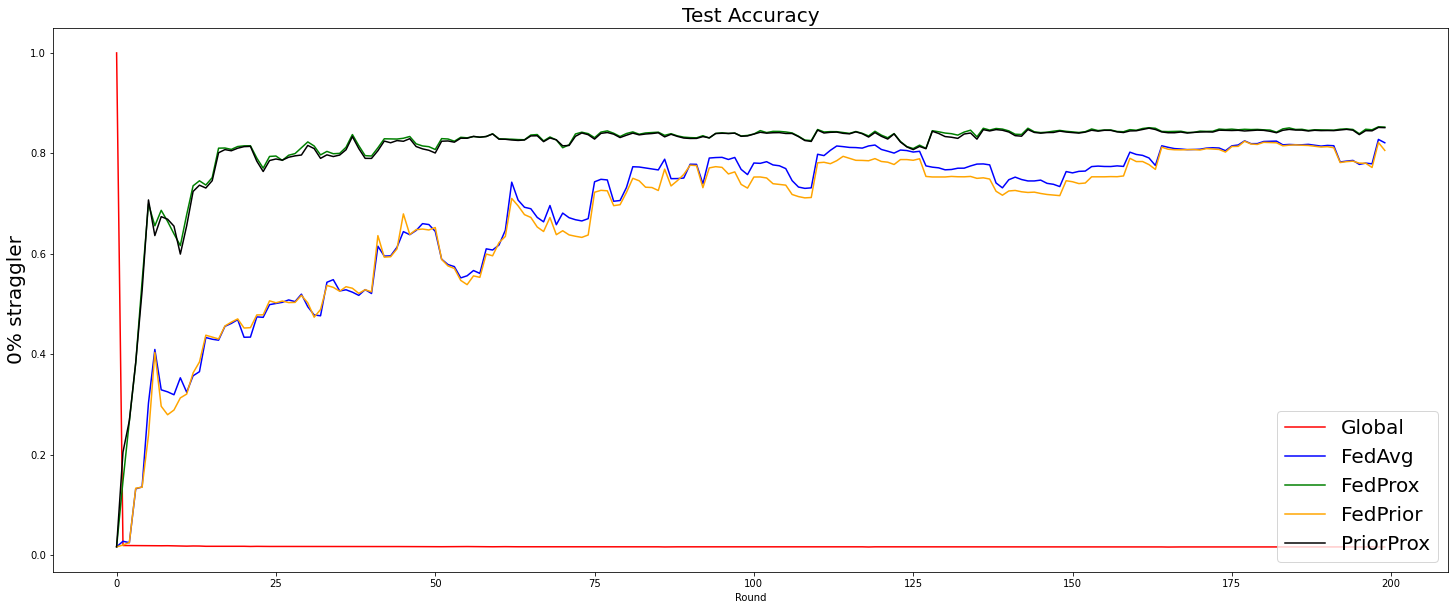

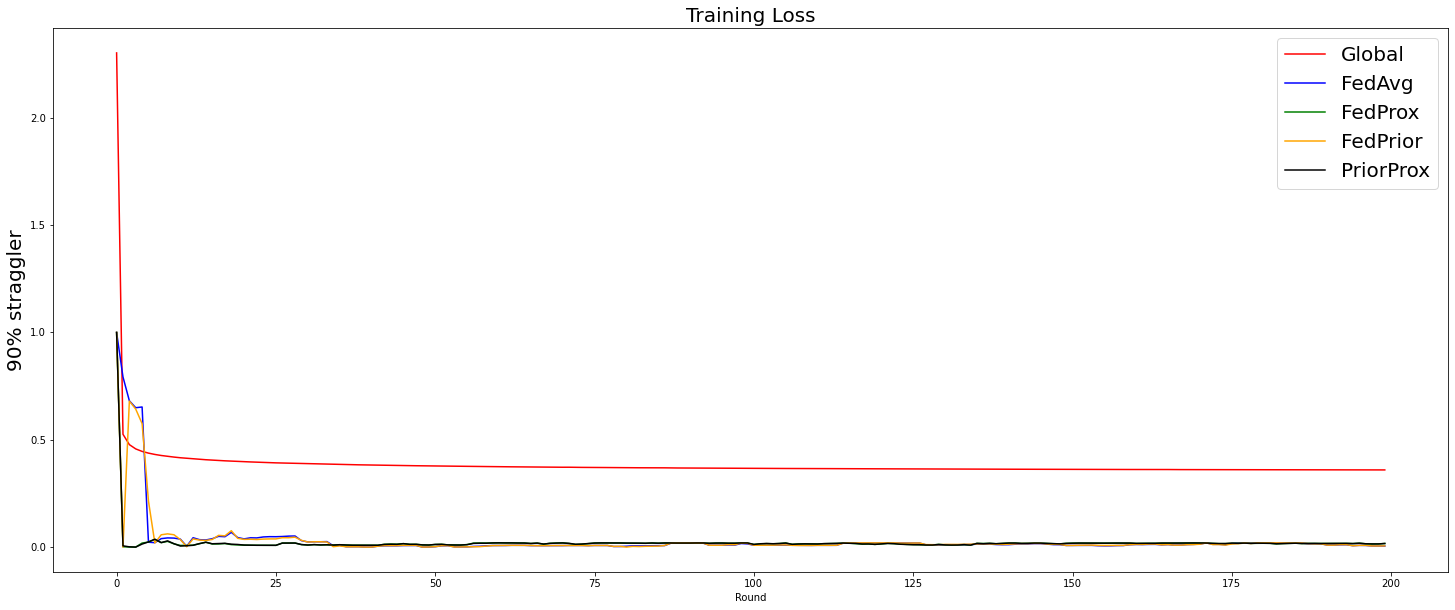

In [27]:
plt.figure(figsize=(25,10))
plt.plot(global_train,color='red')
plt.plot(avg_train_9,color='blue')
plt.plot(prox_train_9,color='green')
plt.plot(prior_train_9,color='orange')
plt.plot(pp_train_9,color='black')
plt.xlabel('Round')
plt.ylabel('90% straggler',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
plt.plot(global_test,color='red')
plt.plot(avg_test_9,color='blue')
plt.plot(prox_test_9,color='green')
plt.plot(prior_test_9,color='orange')
plt.plot(pp_test_9,color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Test Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))

plt.plot(np.squeeze(loss0),color='red')
plt.plot(np.squeeze(loss1_9),color='blue')
plt.plot(np.squeeze(loss2_9),color='green')
plt.plot(np.squeeze(loss3_9),color='orange')
plt.plot(np.squeeze(loss4_9),color='black')
plt.xlabel('Round')
plt.ylabel('90% straggler',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)

# Figure2

## iid

In [28]:
#4
rounds=200
straggler_rate=0.5
select_clients=10
clients_num=30
batchsize=10
beta=1
alpha=1
yita=0.1
#产生数据
X, y,num= generate_synthetic(alpha=alpha, beta=beta, iid=1) 
client_list=[]
for i in range(0,clients_num):
    x1=X[i]
    y1=y[i]
    b=np.ones(len(y1))
    x1=np.c_[x1,b]
    client1=Client(torch.tensor(x1[0:num[i]]),torch.tensor(y1[0:num[i]]))
    client_list.append(client1)
    if i<1:
        test_x=torch.tensor(x1[num[i]:])
        test_y=torch.tensor(y1[num[i]:])
        x_global=torch.tensor(x1[0:num[i]])
        y_global=torch.tensor(y1[0:num[i]])
    elif i>=1:
        test_x=torch.vstack((test_x,torch.tensor(x1[num[i]:])))
        test_y=torch.hstack((test_y,torch.tensor(y1[num[i]:])))
        x_global=torch.vstack((x_global,torch.tensor(x1[0:num[i]])))
        y_global=torch.hstack((y_global,torch.tensor(y1[0:num[i]])))
    
global_client=Client(x_global,y_global)
test_client=Client(test_x,test_y)

global_w_iid,loss0_iid,global_train_iid,global_test_iid=Global(rounds,x_global,y_global,batchsize)
avg_w_iid,loss1_iid,avg_train_iid,avg_test_iid=FedAvg(rounds,client_list,batchsize)
prox_w_iid,loss2_iid=,prox_train_iid,prox_test_iid=FedProx(rounds,client_list,batchsize)
prior_w_iid,loss3_iid,prior_train_iid,prior_test_iid=FedPrior(rounds,client_list,yita,batchsize)
pp_w_iid,loss4_iid,pp_train_iid,pp_test_iid=PriorProx(rounds,client_list,yita,batchsize)

plt.figure(figsize=(25,10))
plt.plot(global_train_iid,color='red')
plt.plot(avg_train_iid,color='blue')
plt.plot(prox_train_iid,color='green')
plt.plot(prior_train_iid,color='orange')
plt.plot(pp_train_iid,color='black')
plt.xlabel('Round')
plt.ylabel('iid',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
plt.plot(global_test_iid,color='red')
plt.plot(avg_test_iid,color='blue')
plt.plot(prox_test_iid,color='green')
plt.plot(prior_test_iid,color='orange')
plt.plot(pp_test_iid,color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Test Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))

plt.plot(np.squeeze(loss0_iid),color='red')
plt.plot(np.squeeze(loss1_iid),color='blue')
plt.plot(np.squeeze(loss2_iid),color='green')
plt.plot(np.squeeze(loss3_iid),color='orange')
plt.plot(np.squeeze(loss4_iid),color='black')
plt.xlabel('Round')
plt.ylabel('iid',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)

SyntaxError: positional argument follows keyword argument (<ipython-input-28-828204b1def0>, line 37)

## sythetic(0.5,0.5)

In [31]:
rounds=200
straggler_rate=0
select_clients=10
clients_num=30
batchsize=10
beta=0.5
alpha=0.5
yita=0.1

In [32]:
#产生数据
X, y,num= generate_synthetic(alpha=alpha, beta=beta, iid=0) 
client_list=[]
for i in range(0,clients_num):
    x1=X[i]
    y1=y[i]
    b=np.ones(len(y1))
    x1=np.c_[x1,b]
    client1=Client(torch.tensor(x1[0:num[i]]),torch.tensor(y1[0:num[i]]))
    client_list.append(client1)
    if i<1:
        test_x=torch.tensor(x1[num[i]:])
        test_y=torch.tensor(y1[num[i]:])
        x_global=torch.tensor(x1[0:num[i]])
        y_global=torch.tensor(y1[0:num[i]])
    elif i>=1:
        test_x=torch.vstack((test_x,torch.tensor(x1[num[i]:])))
        test_y=torch.hstack((test_y,torch.tensor(y1[num[i]:])))
        x_global=torch.vstack((x_global,torch.tensor(x1[0:num[i]])))
        y_global=torch.hstack((y_global,torch.tensor(y1[0:num[i]])))
    
global_client=Client(x_global,y_global)
test_client=Client(test_x,test_y)

In [ ]:
global_w_0505,loss0_0505,global_train_0505,global_test_0505=Global(rounds,global_client,batchsize)
avg_w_0505,loss1_0505,avg_train_0505,avg_test_0505=FedAvg(rounds,client_list,batchsize)
prox_w_0505,loss2_0505,prox_train_0505,prox_test_0505=FedProx(rounds,client_list,batchsize)
prior_w_0505,loss3_0505,prior_train_0505,prior_test_0505=FedPrior(rounds,client_list,yita,batchsize)
pp_w_0505,loss4_0505,pp_train_0505,pp_test_0505=PriorProx(rounds,client_list,yita,batchsize)

In [ ]:
plt.figure(figsize=(25,10))
plt.plot(global_train_0505,color='red')
plt.plot(avg_train_0505,color='blue')
plt.plot(prox_train_0505,color='green')
plt.plot(prior_train_0505,color='orange')
plt.plot(pp_train_0505,color='black')
plt.xlabel('Round')
plt.ylabel('sythetic(0.5,0.5)',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)
plt.show()

plt.figure(figsize=(25,10))
plt.plot(global_test_0505,color='red')
plt.plot(avg_test_0505,color='blue')
plt.plot(prox_test_0505,color='green')
plt.plot(prior_test_0505,color='orange')
plt.plot(pp_test_0505,color='black')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Test Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
#plt.ylim((-0.1,0.5))
plt.plot(np.squeeze(loss0_0505),color='red')
plt.plot(np.squeeze(loss1_0505),color='blue')
plt.plot(np.squeeze(loss2_0505),color='green')
plt.plot(np.squeeze(loss3_0505),color='orange')
plt.plot(np.squeeze(loss4_0505),color='black')
plt.xlabel('Round')
plt.ylabel('sythetic(0.5,0.5)',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)
plt.show()